In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

In [23]:
train.shape

(1460, 81)

In [24]:
test.shape

(1459, 80)

In [32]:
target = train['SalePrice']
train.drop(columns=['SalePrice'], inplace=True)


In [33]:
missing_values=train.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(inplace=True)

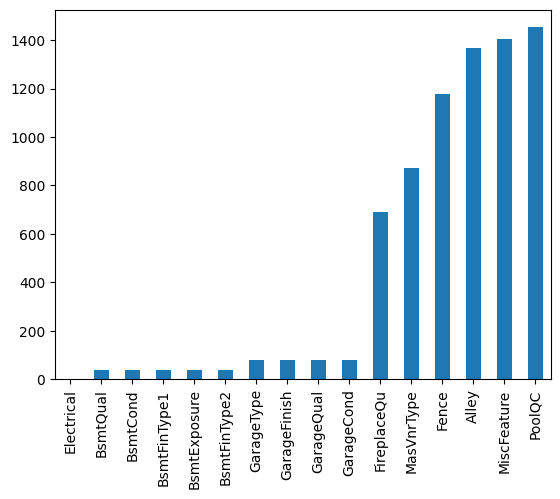

In [34]:
missing_values.plot.bar()
plt.show()

In [35]:
num_features = train.select_dtypes(include=[np.number]).columns
cat_features = train.select_dtypes(include=[object]).columns

In [36]:
for feature in num_features:
    train[feature] = train[feature].fillna(train[feature].median())
    if feature in test.columns:
        test[feature] = test[feature].fillna(test[feature].median())

In [37]:
for feature in cat_features:
    train[feature] = train[feature].fillna(train[feature].mode()[0])
    if feature in test.columns:
        test[feature] = test[feature].fillna(test[feature].mode()[0])

In [38]:
label_encoders = {}
for feature in cat_features:
    label_encoders[feature] = LabelEncoder()
    train[feature] = label_encoders[feature].fit_transform(train[feature])
    if feature in test.columns:
        test[feature] = label_encoders[feature].transform(test[feature])


In [39]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

In [40]:
train['TotalBath'] = train['FullBath'] + 0.5 * train['HalfBath'] + train['BsmtFullBath'] + 0.5 * train['BsmtHalfBath']
test['TotalBath'] = test['FullBath'] + 0.5 * test['HalfBath'] + test['BsmtFullBath'] + 0.5 * test['BsmtHalfBath']

In [41]:
scaler = StandardScaler()
train[num_features] = scaler.fit_transform(train[num_features])
test[num_features] = scaler.transform(test[num_features])


In [42]:
print(train.shape)
print(test.shape)

(1460, 82)
(1459, 82)
